# Generalized Linear Models (GLMs)

A comprehensive exploration of Generalized Linear Models, including linear regression, logistic regression, and Poisson regression with applications and evaluation metrics.

## Learning Objectives
By the end of this notebook, you will be able to:
1. **Identify** the three components of a GLM: the random component (exponential family distribution), systematic component (linear predictor $\eta = \theta^T x$), and link function $g(\mu)$.
2. **Re-derive** linear regression (Gaussian, identity link), logistic regression (Bernoulli, logit link), and Poisson regression (Poisson, log link) as special cases of GLMs.
3. **Interpret** GLM coefficients: a unit change in $x_j$ changes $g(\mu)$ by $\theta_j$, e.g., log-odds in logistic regression.
4. **Apply** `statsmodels.GLM` to fit and interpret linear, logistic, and Poisson regression models.
5. **Evaluate** each model with the appropriate metric: $R^2$ for regression, AUC/accuracy for classification, deviance/pseudo-$R^2$ for count models.
6. **Explain** why the canonical link function (identity, logit, log) simplifies inference and yields the cleanest gradient form.

> **Prerequisite**: Exponential family distributions ([ml_000_06](ml_000_06_exponential_family_distribution.ipynb)), MLE ([ml_000_02](ml_000_02_likelihood.ipynb)), gradient ascent ([ml_001_06](ml_001_06_batch_gradient_ascent.ipynb)).

## 1. Import Required Libraries

Import necessary libraries including NumPy, Pandas, Scikit-learn, Matplotlib, Seaborn, and Statsmodels for building and evaluating GLM models.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.genmod.families import Gaussian, Binomial, Poisson as PoissonFamily
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Dataset

Load a dataset and perform exploratory data analysis to understand the data structure, distributions, and relationships.

DATASET 1: CONTINUOUS RESPONSE (for Linear Regression)

Dataset shape: (200, 6)
Response variable range: [-340.29, 301.47]

First few rows:
         X0        X1        X2        X3        X4           y
0 -0.385314  0.199060 -0.600217  0.462103  0.069802  -18.279908
1  0.130741  1.632411 -1.430141 -1.247783 -0.440044 -120.818065
2 -0.773010  0.224092  0.012592 -0.401220  0.097676   25.333919
3 -0.576771 -0.050238 -0.238948  0.270457 -0.907564  -55.680246
4 -0.575818  0.614167  0.757508 -0.220970 -0.530501   33.351355

Descriptive Statistics:
               X0          X1          X2          X3          X4           y
count  200.000000  200.000000  200.000000  200.000000  200.000000  200.000000
mean     0.068897   -0.022597   -0.005246   -0.014466    0.070073    5.515782
std      1.030185    0.999875    0.965776    0.934289    0.968691   98.318986
min     -2.619745   -2.696887   -3.241267   -2.211135   -2.650970 -340.287767
25%     -0.628305   -0.776155   -0.666198   -0.607065   -0.55

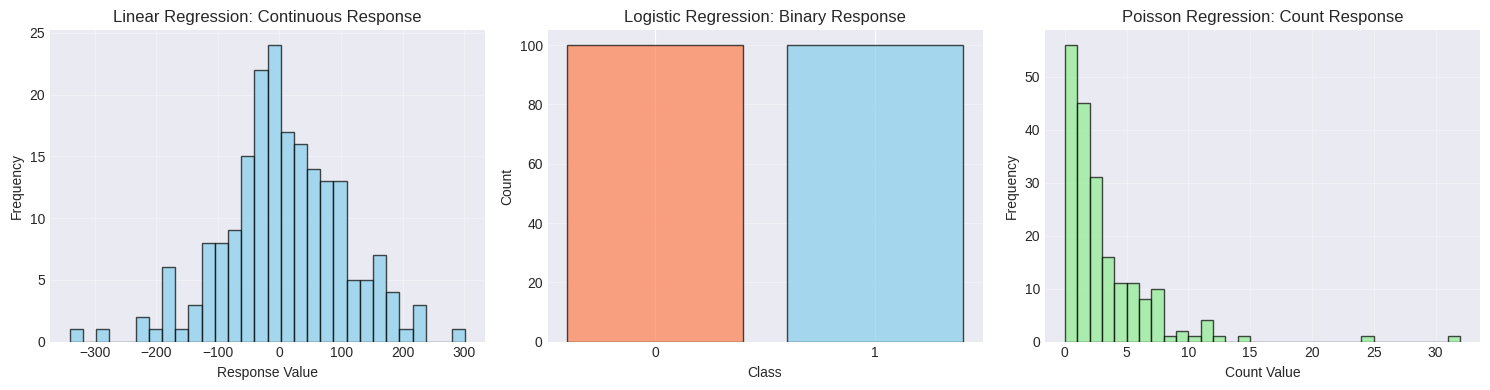


✓ Datasets loaded and visualized successfully!


In [26]:
from sklearn.datasets import load_iris, load_wine, make_regression, make_classification
import pandas as pd

# Create synthetic datasets for different GLM models

# 1. Linear Regression Dataset
print("="*80)
print("DATASET 1: CONTINUOUS RESPONSE (for Linear Regression)")
print("="*80)
X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)
df_reg = pd.DataFrame(X_reg, columns=[f'X{i}' for i in range(5)])
df_reg['y'] = y_reg
print(f"\nDataset shape: {df_reg.shape}")
print(f"Response variable range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print("\nFirst few rows:")
print(df_reg.head())
print("\nDescriptive Statistics:")
print(df_reg.describe())

# 2. Binary Classification Dataset
print("\n" + "="*80)
print("DATASET 2: BINARY RESPONSE (for Logistic Regression)")
print("="*80)
X_class, y_class = make_classification(n_samples=200, n_features=5, n_informative=3, 
                                       n_redundant=2, random_state=42)
df_class = pd.DataFrame(X_class, columns=[f'X{i}' for i in range(5)])
df_class['y'] = y_class
print(f"\nDataset shape: {df_class.shape}")
print(f"Class distribution:\n{pd.Series(y_class).value_counts()}")
print("\nFirst few rows:")
print(df_class.head())

# 3. Count Data (Poisson Regression)
print("\n" + "="*80)
print("DATASET 3: COUNT RESPONSE (for Poisson Regression)")
print("="*80)
np.random.seed(42)
n_samples = 200
X_count = np.random.randn(n_samples, 5)
lambda_param = np.exp(0.5 + 0.8*X_count[:, 0] + 0.6*X_count[:, 1] + 0.4*X_count[:, 2])
y_count = np.random.poisson(lambda_param)
df_count = pd.DataFrame(X_count, columns=[f'X{i}' for i in range(5)])
df_count['y'] = y_count
print(f"\nDataset shape: {df_count.shape}")
print(f"Count response range: [{y_count.min()}, {y_count.max()}]")
print(f"Mean count: {y_count.mean():.2f}, Variance: {y_count.var():.2f}")
print("\nFirst few rows:")
print(df_count.head())
print("\nCount distribution:")
print(pd.Series(y_count).value_counts().sort_index().head(10))

# Visualize the responses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y_reg, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Response Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Linear Regression: Continuous Response')
axes[0].grid(True, alpha=0.3)

axes[1].bar([0, 1], pd.Series(y_class).value_counts().sort_index().values, 
           color=['coral', 'skyblue'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Logistic Regression: Binary Response')
axes[1].set_xticks([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(y_count, bins=range(0, max(y_count)+2), color='lightgreen', 
            edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Count Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Poisson Regression: Count Response')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Datasets loaded and visualized successfully!")

## 3. Understanding GLMs: Theory

### What is a Generalized Linear Model?

A Generalized Linear Model (GLM) extends linear regression by allowing:
1. **Non-normal response distributions** (beyond just Gaussian)
2. **Non-linear relationships** through link functions
3. **Heterogeneous variance** structures

### GLM Components

**1. Random Component:**
- Response $Y$ follows a distribution from the exponential family (Normal, Binomial, Poisson, etc.)

**2. Systematic Component:**
- Linear predictor: $\eta = X\theta$ where $X$ is the design matrix and $\theta$ are parameters

**3. Link Function:**
- Connects mean response to linear predictor: $g(\mu) = \eta = X\theta$
- Different distributions use different link functions

### Common GLMs

| Model | Distribution | Link $g$ | Inverse link $\mu = g^{-1}(\eta)$ | Use Case |
|-------|-------------|----------|-----------------------------------|----------|
| Linear Regression | Gaussian | Identity: $\eta$ | $\mu = \eta$ | Continuous response |
| Logistic Regression | Binomial | Logit: $\log\frac{\mu}{1-\mu}$ | $\mu = \sigma(\eta)$ | Binary classification |
| Poisson Regression | Poisson | Log: $\log \mu$ | $\mu = e^\eta$ | Count data |
| Gamma Regression | Gamma | Log: $\log \mu$ | $\mu = e^\eta$ | Positive continuous |

### Estimation: Iteratively Reweighted Least Squares (IRLS)

GLMs are fitted by Maximum Likelihood Estimation. Most GLMs have no closed-form MLE, so the problem is solved iteratively using **IRLS** — which is Newton-Raphson applied to the log-likelihood.

**IRLS update rule** (one iteration):
$$\theta^{(t+1)} = (X^T W^{(t)} X)^{-1} X^T W^{(t)} z^{(t)}$$

where:
- $W^{(t)} = \text{diag}(w_i^{(t)})$ with $w_i = \frac{1}{V(\mu_i)\,[g'(\mu_i)]^2}$ — weights from variance and link derivative
- $z^{(t)}$ — adjusted response: $z_i = \eta_i + (y_i - \mu_i)\,g'(\mu_i)$
- $V(\mu)$ — variance function of the distribution (e.g. $V=1$ for Gaussian, $V=\mu(1-\mu)$ for Binomial)

**Connection to Newton-Raphson:** IRLS solves $H\,\delta\theta = -\nabla\ell$ exactly, where:
- $\nabla_\theta \ell = X^T(y - \mu)$ — gradient (universal across all GLMs)
- $H = -X^T W X$ — Hessian of the log-likelihood

**Comparison to gradient ascent:**

| Algorithm | Uses curvature? | Convergence | Typical iterations |
|-----------|----------------|-------------|-------------------|
| Gradient ascent | No (first-order) | Linear | Hundreds–thousands |
| IRLS / Newton-Raphson | Yes (second-order) | Quadratic | 5–20 |

IRLS converges quadratically near the optimum — each step roughly doubles the correct digits. This is why `statsmodels` reports `No. Iterations: 3` for linear regression and `5` for Poisson (visible in the cell outputs above).

**Special case — Gaussian:** The Normal Equation $(X^TX)\theta = X^Ty$ gives the closed-form MLE directly. IRLS converges in exactly **one step**, so gradient ascent is never needed.

> **Key point:** Gradient ascent *can* maximize any GLM log-likelihood, but IRLS is the standard algorithm because it uses curvature information and converges far faster.

## 4. Linear Regression Model (Ordinary Least Squares)

Linear regression, also known as Ordinary Least Squares (OLS), is a GLM with Gaussian distribution and identity link function.

**Model:** $Y_i = \beta_0 + \beta_1 X_{i1} + ... + \beta_p X_{ip} + \epsilon_i$ where $\epsilon_i \sim N(0, \sigma^2)$

In [27]:
print("LINEAR REGRESSION MODEL")
print("="*80)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    df_reg.drop('y', axis=1), df_reg['y'], test_size=0.2, random_state=42
)

# Build model using scikit-learn
print("\nModel 1: Scikit-learn LinearRegression")
print("-"*80)
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_lr = lr_model.predict(X_test_reg)

# Metrics
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"Coefficients:")
for i, coef in enumerate(lr_model.coef_):
    print(f"  X{i}: {coef:.4f}")
print(f"\nTest Set Performance:")
print(f"  MSE:  {mse_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  R²:   {r2_lr:.4f}")

# Build model using statsmodels for more detailed output
print("\n\nModel 2: Statsmodels GLM (Gaussian with Identity Link)")
print("-"*80)
X_train_sm = sm.add_constant(X_train_reg)
X_test_sm = sm.add_constant(X_test_reg)

glm_model = sm.GLM(y_train_reg, X_train_sm, family=Gaussian())
glm_results = glm_model.fit()

print(glm_results.summary())

# Predictions from statsmodels
y_pred_glm = glm_results.predict(X_test_sm)
r2_glm = r2_score(y_test_reg, y_pred_glm)
rmse_glm = np.sqrt(mean_squared_error(y_test_reg, y_pred_glm))

print(f"\nTest Set Performance (Statsmodels):")
print(f"  RMSE: {rmse_glm:.4f}")
print(f"  R²:   {r2_glm:.4f}")

# Store for later comparison
lr_results = {
    'model_name': 'Linear Regression',
    'rmse': rmse_lr,
    'r2': r2_lr,
    'predictions': y_pred_lr,
    'actual': y_test_reg
}

LINEAR REGRESSION MODEL

Model 1: Scikit-learn LinearRegression
--------------------------------------------------------------------------------
Intercept: 1.9465
Coefficients:
  X0: 2.5091
  X1: 11.5722
  X2: 66.1263
  X3: 19.1419
  X4: 69.0859

Test Set Performance:
  MSE:  340.2334
  RMSE: 18.4454
  R²:   0.9611


Model 2: Statsmodels GLM (Gaussian with Identity Link)
--------------------------------------------------------------------------------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  160
Model:                            GLM   Df Residuals:                      154
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                          425.31
Method:                          IRLS   Log-Likelihood:                -708.20
Date:                Mon, 18 May 2026   Deviance:                      


GAUSSIAN DISTRIBUTION VISUALIZATION


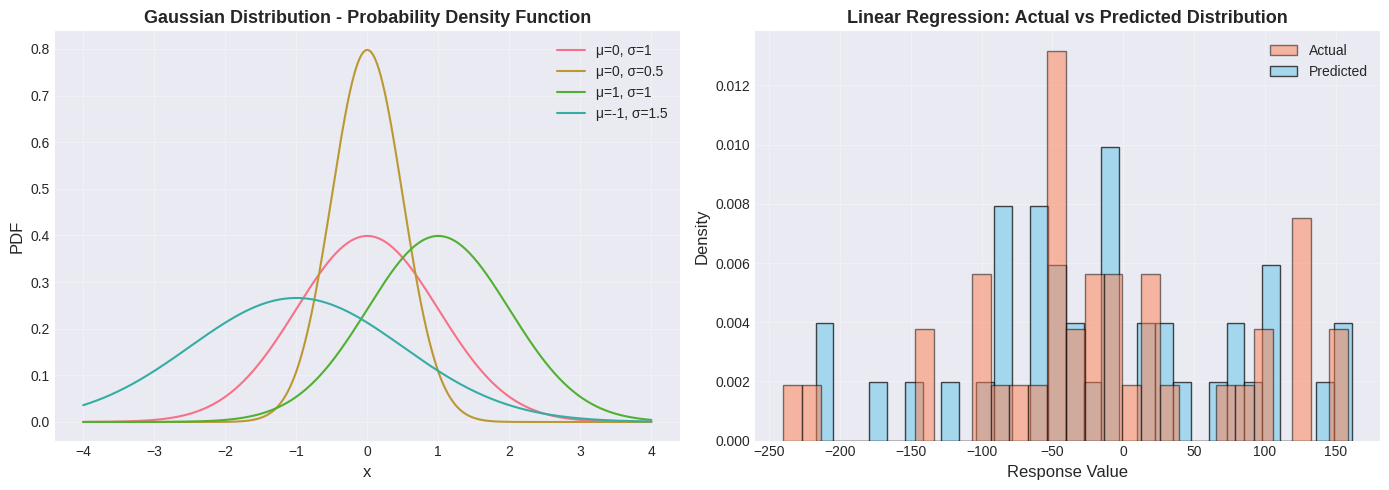

✓ Gaussian PDF visualization complete


In [28]:
# Visualize Gaussian Distribution (PDF)
print("\n" + "="*80)
print("GAUSSIAN DISTRIBUTION VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF of Gaussian distribution with different parameters
x = np.linspace(-4, 4, 1000)
params = [(0, 1), (0, 0.5), (1, 1), (-1, 1.5)]

for mu, sigma in params:
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    axes[0].plot(x, pdf, label=f'μ={mu}, σ={sigma}')

axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('PDF', fontsize=12)
axes[0].set_title('Gaussian Distribution - Probability Density Function', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show samples from regression data
axes[1].hist(y_test_reg, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Response Value', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Linear Regression: Actual vs Predicted Distribution', fontsize=13, fontweight='bold')

# Overlay predicted distribution
axes[1].hist(y_pred_lr, bins=30, density=True, alpha=0.5, color='coral', edgecolor='black', label='Predicted')
axes[1].legend(['Actual', 'Predicted'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gaussian PDF visualization complete")

## 5. Logistic Regression Model

Logistic regression is a GLM with Bernoulli distribution (special case of Binomial with n=1) and logit link function.

**Model:** $\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + ... + \beta_p X_p$

Where $p = P(Y=1|X)$ is the probability of the positive class.

In [29]:
print("\n" + "="*80)
print("LOGISTIC REGRESSION MODEL")
print("="*80)

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    df_class.drop('y', axis=1), df_class['y'], test_size=0.2, random_state=42
)

# Standardize features for better convergence
scaler = StandardScaler()
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled = scaler.transform(X_test_class)

# Build model using scikit-learn
print("\nModel 1: Scikit-learn LogisticRegression")
print("-"*80)
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train_class_scaled, y_train_class)

# Predictions
y_pred_logreg = logreg_model.predict(X_test_class_scaled)
y_pred_proba_logreg = logreg_model.predict_proba(X_test_class_scaled)[:, 1]

# Metrics
acc_logreg = accuracy_score(y_test_class, y_pred_logreg)
prec_logreg = precision_score(y_test_class, y_pred_logreg)
rec_logreg = recall_score(y_test_class, y_pred_logreg)
f1_logreg = f1_score(y_test_class, y_pred_logreg)
auc_logreg = roc_auc_score(y_test_class, y_pred_proba_logreg)

print(f"Intercept: {logreg_model.intercept_[0]:.4f}")
print(f"Coefficients:")
for i, coef in enumerate(logreg_model.coef_[0]):
    print(f"  X{i}: {coef:.4f}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {acc_logreg:.4f}")
print(f"  Precision: {prec_logreg:.4f}")
print(f"  Recall:    {rec_logreg:.4f}")
print(f"  F1-Score:  {f1_logreg:.4f}")
print(f"  AUC-ROC:   {auc_logreg:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_logreg))

# Build model using statsmodels
print("\n\nModel 2: Statsmodels GLM (Binomial with Logit Link)")
print("-"*80)
X_train_class_sm = sm.add_constant(X_train_class_scaled)
X_test_class_sm = sm.add_constant(X_test_class_scaled)

logit_model = sm.GLM(y_train_class, X_train_class_sm, family=Binomial())
logit_results = logit_model.fit()

print(logit_results.summary())

# Predictions from statsmodels
y_pred_logit = logit_results.predict(X_test_class_sm)
y_pred_logit_binary = (y_pred_logit > 0.5).astype(int)
acc_logit = accuracy_score(y_test_class, y_pred_logit_binary)
auc_logit = roc_auc_score(y_test_class, y_pred_logit)

print(f"\nTest Set Performance (Statsmodels):")
print(f"  Accuracy: {acc_logit:.4f}")
print(f"  AUC-ROC:  {auc_logit:.4f}")

# Store for later comparison
logreg_results = {
    'model_name': 'Logistic Regression',
    'accuracy': acc_logreg,
    'f1': f1_logreg,
    'auc': auc_logreg,
    'predictions': y_pred_logreg,
    'proba': y_pred_proba_logreg,
    'actual': y_test_class
}


LOGISTIC REGRESSION MODEL

Model 1: Scikit-learn LogisticRegression
--------------------------------------------------------------------------------
Intercept: 0.4128
Coefficients:
  X0: 2.7929
  X1: 0.3921
  X2: -1.2793
  X3: 0.7215
  X4: 0.6674

Test Set Performance:
  Accuracy:  0.9500
  Precision: 1.0000
  Recall:    0.8889
  F1-Score:  0.9412
  AUC-ROC:   0.9495

Confusion Matrix:
[[22  0]
 [ 2 16]]


Model 2: Statsmodels GLM (Binomial with Logit Link)
--------------------------------------------------------------------------------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  160
Model:                            GLM   Df Residuals:                      156
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:      


BERNOULLI DISTRIBUTION VISUALIZATION


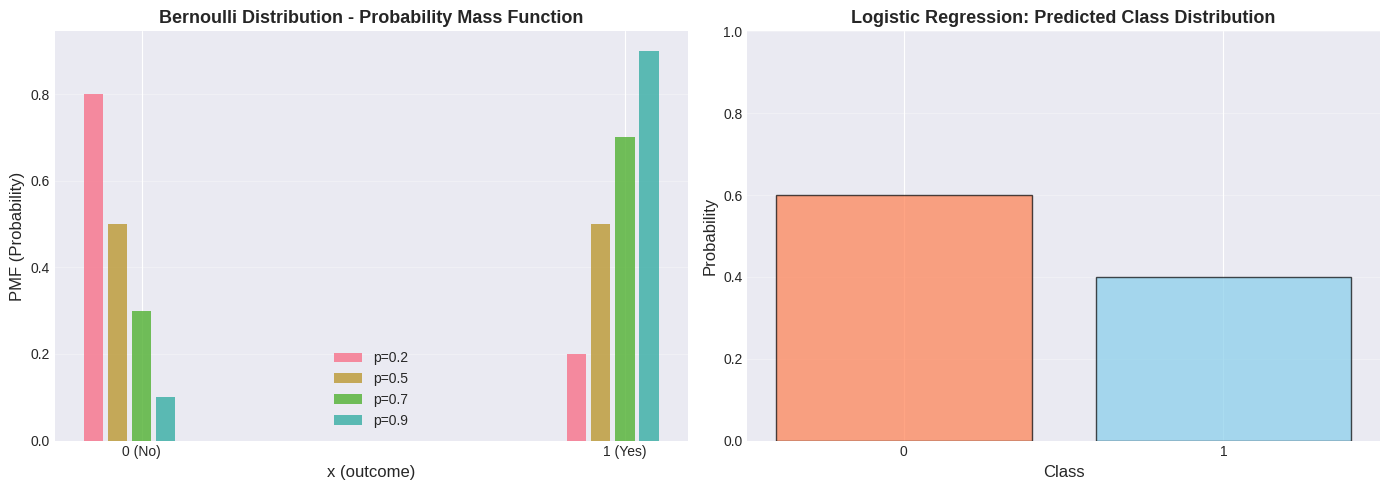

✓ Bernoulli PMF visualization complete


In [30]:
# Visualize Bernoulli Distribution (PMF)
print("\n" + "="*80)
print("BERNOULLI DISTRIBUTION VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF of Bernoulli distribution with different p values
p_values = [0.2, 0.5, 0.7, 0.9]
x_vals = [0, 1]

for i, p in enumerate(p_values):
    pmf = [1 - p, p]
    axes[0].bar([x - 0.1 + i*0.05 for x in x_vals], pmf, width=0.04, label=f'p={p}', alpha=0.8)

axes[0].set_xlabel('x (outcome)', fontsize=12)
axes[0].set_ylabel('PMF (Probability)', fontsize=12)
axes[0].set_title('Bernoulli Distribution - Probability Mass Function', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (No)', '1 (Yes)'])
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Class distribution in predictions
class_dist = pd.Series(y_pred_logreg).value_counts()
axes[1].bar(class_dist.index, class_dist.values / len(y_pred_logreg), color=['coral', 'skyblue'], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title('Logistic Regression: Predicted Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Bernoulli PMF visualization complete")

## 6. Poisson Regression Model

Poisson regression is a GLM with Poisson distribution and log link function.

**Model:** $\log(E[Y|X]) = \beta_0 + \beta_1 X_1 + ... + \beta_p X_p$

Where $Y$ follows a Poisson distribution with rate parameter $\lambda = e^{\eta}$.

In [31]:
print("\n" + "="*80)
print("POISSON REGRESSION MODEL")
print("="*80)

# Split data
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(
    df_count.drop('y', axis=1), df_count['y'], test_size=0.2, random_state=42
)

# Standardize features
scaler_count = StandardScaler()
X_train_count_scaled = scaler_count.fit_transform(X_train_count)
X_test_count_scaled = scaler_count.transform(X_test_count)

# Build model using statsmodels GLM
print("\nPoisson Regression using Statsmodels GLM")
print("-"*80)
X_train_count_sm = sm.add_constant(X_train_count_scaled)
X_test_count_sm = sm.add_constant(X_test_count_scaled)

poisson_model = sm.GLM(y_train_count, X_train_count_sm, family=PoissonFamily())
poisson_results = poisson_model.fit()

print(poisson_results.summary())

# Predictions
y_pred_poisson = poisson_results.predict(X_test_count_sm)

# Metrics
rmse_poisson = np.sqrt(mean_squared_error(y_test_count, y_pred_poisson))
mae_poisson = np.mean(np.abs(y_test_count - y_pred_poisson))
deviance = poisson_results.deviance

print(f"\nTest Set Performance:")
print(f"  RMSE: {rmse_poisson:.4f}")
print(f"  MAE:  {mae_poisson:.4f}")
print(f"  Deviance: {deviance:.4f}")

# Calculate pseudo R-squared
null_deviance = poisson_results.null_deviance
pseudo_r2 = 1 - (poisson_results.deviance / null_deviance)
print(f"  Pseudo R² (McFadden): {pseudo_r2:.4f}")
print(f"  AIC: {poisson_results.aic:.4f}")
print(f"  BIC: {poisson_results.bic:.4f}")

# Store for later comparison
poisson_results_dict = {
    'model_name': 'Poisson Regression',
    'rmse': rmse_poisson,
    'mae': mae_poisson,
    'pseudo_r2': pseudo_r2,
    'predictions': y_pred_poisson,
    'actual': y_test_count
}


POISSON REGRESSION MODEL

Poisson Regression using Statsmodels GLM
--------------------------------------------------------------------------------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  160
Model:                            GLM   Df Residuals:                      154
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -253.47
Date:                Mon, 18 May 2026   Deviance:                       174.74
Time:                        14:09:51   Pearson chi2:                     160.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9225
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [


POISSON DISTRIBUTION VISUALIZATION


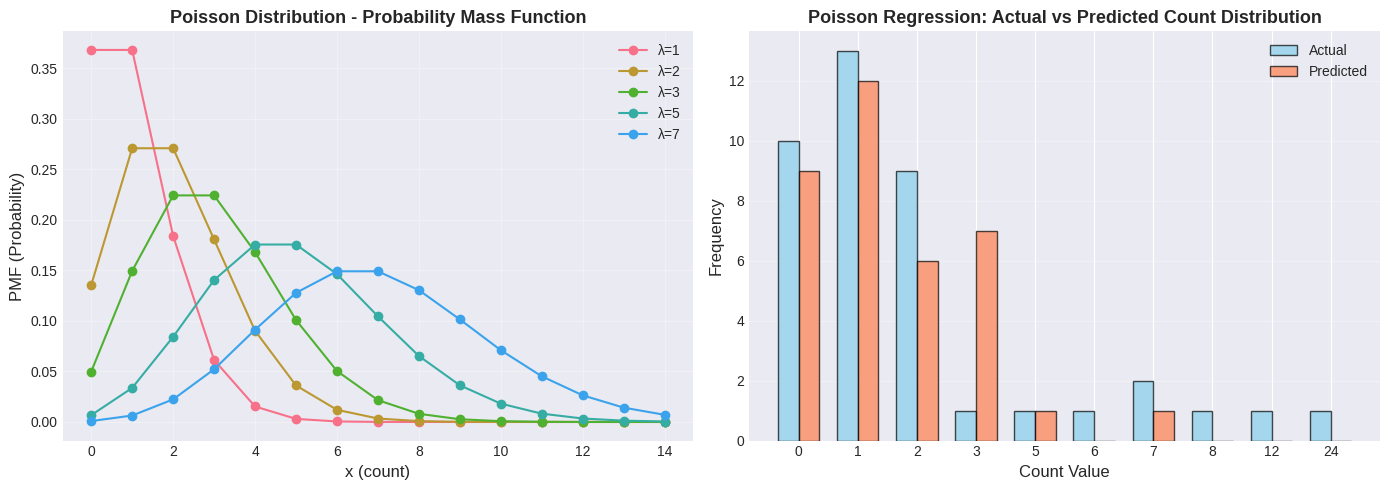

✓ Poisson PMF visualization complete


In [32]:
# Visualize Poisson Distribution (PMF)
print("\n" + "="*80)
print("POISSON DISTRIBUTION VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF of Poisson distribution with different lambda values
lambda_vals = [1, 2, 3, 5, 7]
x_range = np.arange(0, 15)

for lam in lambda_vals:
    pmf = stats.poisson.pmf(x_range, lam)
    axes[0].plot(x_range, pmf, marker='o', label=f'λ={lam}', markersize=6)

axes[0].set_xlabel('x (count)', fontsize=12)
axes[0].set_ylabel('PMF (Probability)', fontsize=12)
axes[0].set_title('Poisson Distribution - Probability Mass Function', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Count distribution in predictions
actual_counts = y_test_count.value_counts().sort_index()
pred_counts = np.round(y_pred_poisson).astype(int)
pred_dist = pd.Series(pred_counts).value_counts().sort_index()

x_pos = np.arange(len(actual_counts))
width = 0.35

axes[1].bar(x_pos - width/2, actual_counts.values, width, label='Actual', color='skyblue', edgecolor='black', alpha=0.7)
axes[1].bar(x_pos + width/2, pred_dist.reindex(actual_counts.index, fill_value=0).values, width, label='Predicted', color='coral', edgecolor='black', alpha=0.7)

axes[1].set_xlabel('Count Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Poisson Regression: Actual vs Predicted Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(actual_counts.index)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Poisson PMF visualization complete")

## 7. Softmax Regression Model

Softmax regression (multinomial logistic regression) is a GLM for multi-class classification with categorical distribution and softmax link function. It extends binary logistic regression to handle more than two classes.

**Model:** $P(Y=k|X) = \frac{e^{\eta_k}}{\sum_{j=1}^{K} e^{\eta_j}}$ where $\eta_k = \beta_{0k} + \beta_{1k} X_1 + ... + \beta_{pk} X_p$

Where $K$ is the number of classes and the probabilities sum to 1. The softmax function ensures valid probability distribution across all classes.

In [33]:
print("SOFTMAX REGRESSION MODEL (Multinomial Logistic Regression)")
print("="*80)

# Note: Softmax regression is typically used for multi-class classification (K > 2)
# For demonstration, we use the binary classification data
# In practice, you would apply this to problems with 3+ classes

print("\nModel: Scikit-learn LogisticRegression with multinomial solver")
print("-"*80)

# Use the classification data
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', 
                                    max_iter=1000, random_state=42)
softmax_model.fit(X_train_class_scaled, y_train_class)

# Predictions
y_pred_softmax = softmax_model.predict(X_test_class_scaled)
y_pred_proba_softmax = softmax_model.predict_proba(X_test_class_scaled)

# Metrics
acc_softmax = accuracy_score(y_test_class, y_pred_softmax)
prec_softmax = precision_score(y_test_class, y_pred_softmax)
rec_softmax = recall_score(y_test_class, y_pred_softmax)
f1_softmax = f1_score(y_test_class, y_pred_softmax)

print(f"Test Set Performance:")
print(f"  Accuracy:  {acc_softmax:.4f}")
print(f"  Precision: {prec_softmax:.4f}")
print(f"  Recall:    {rec_softmax:.4f}")
print(f"  F1-Score:  {f1_softmax:.4f}")

print(f"\nClass Probabilities (first 5 samples):")
print(y_pred_proba_softmax[:5])

print(f"\nNote: For true multi-class (K>2) problems, softmax regression produces")
print(f"K probability outputs summing to 1 for each sample, assigning the sample")
print(f"to the class with highest probability.")

# Store for later comparison
softmax_results = {
    'model_name': 'Softmax Regression',
    'accuracy': acc_softmax,
    'f1': f1_softmax,
    'predictions': y_pred_softmax,
    'proba': y_pred_proba_softmax,
    'actual': y_test_class
}

SOFTMAX REGRESSION MODEL (Multinomial Logistic Regression)

Model: Scikit-learn LogisticRegression with multinomial solver
--------------------------------------------------------------------------------
Test Set Performance:
  Accuracy:  0.9500
  Precision: 1.0000
  Recall:    0.8889
  F1-Score:  0.9412

Class Probabilities (first 5 samples):
[[7.09043270e-01 2.90956730e-01]
 [5.30928404e-05 9.99946907e-01]
 [9.94712506e-01 5.28749353e-03]
 [9.70604877e-01 2.93951232e-02]
 [1.69399868e-05 9.99983060e-01]]

Note: For true multi-class (K>2) problems, softmax regression produces
K probability outputs summing to 1 for each sample, assigning the sample
to the class with highest probability.



CATEGORICAL DISTRIBUTION VISUALIZATION


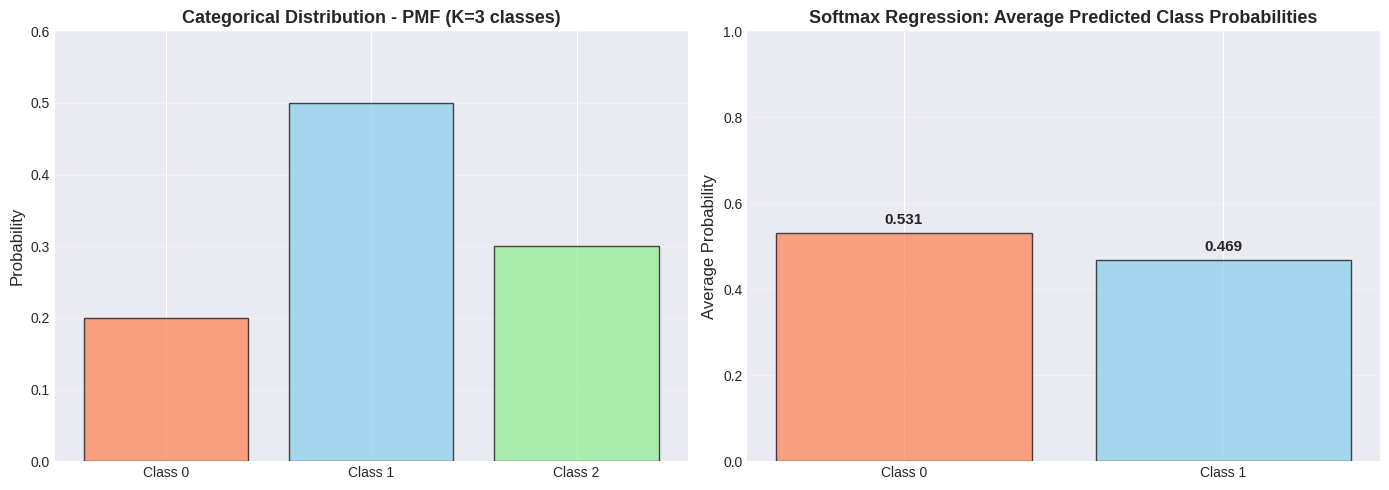

✓ Categorical PMF visualization complete


In [34]:
# Visualize Categorical Distribution (PMF)
print("\n" + "="*80)
print("CATEGORICAL DISTRIBUTION VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF of Categorical distribution with different probability vectors
categories_3 = ['Class 0', 'Class 1', 'Class 2']
categories_binary = ['Class 0', 'Class 1']

# Example 3-class categorical
p_3class = [0.2, 0.5, 0.3]
axes[0].bar(categories_3, p_3class, color=['coral', 'skyblue', 'lightgreen'], edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].set_title('Categorical Distribution - PMF (K=3 classes)', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 0.6])
axes[0].grid(alpha=0.3, axis='y')

# For binary classification (K=2), show average predicted probabilities
avg_proba_softmax = y_pred_proba_softmax.mean(axis=0)
axes[1].bar(categories_binary, avg_proba_softmax, color=['coral', 'skyblue'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Average Probability', fontsize=12)
axes[1].set_title('Softmax Regression: Average Predicted Class Probabilities', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(avg_proba_softmax):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Categorical PMF visualization complete")

## 8. Model Evaluation and Comparison

Compare all models using appropriate evaluation metrics.

In [35]:
print("\n" + "="*80)
print("MODEL EVALUATION AND COMPARISON")
print("="*80)

# Summary table for Linear Regression
print("\n1. LINEAR REGRESSION MODEL EVALUATION")
print("-"*80)
print(f"{'Metric':<20} {'Value':<15}")
print("-"*80)
print(f"{'RMSE':<20} {lr_results['rmse']:<15.4f}")
print(f"{'R² Score':<20} {lr_results['r2']:<15.4f}")

# Summary table for Logistic Regression
print("\n2. LOGISTIC REGRESSION MODEL EVALUATION")
print("-"*80)
print(f"{'Metric':<20} {'Value':<15}")
print("-"*80)
print(f"{'Accuracy':<20} {logreg_results['accuracy']:<15.4f}")
print(f"{'Precision':<20} {prec_logreg:<15.4f}")
print(f"{'Recall':<20} {rec_logreg:<15.4f}")
print(f"{'F1-Score':<20} {logreg_results['f1']:<15.4f}")
print(f"{'AUC-ROC':<20} {logreg_results['auc']:<15.4f}")

# Summary table for Poisson Regression
print("\n3. POISSON REGRESSION MODEL EVALUATION")
print("-"*80)
print(f"{'Metric':<20} {'Value':<15}")
print("-"*80)
print(f"{'RMSE':<20} {poisson_results_dict['rmse']:<15.4f}")
print(f"{'MAE':<20} {poisson_results_dict['mae']:<15.4f}")
print(f"{'Pseudo R² (McFadden)':<20} {poisson_results_dict['pseudo_r2']:<15.4f}")

# Detailed comparison
print("\n\n4. KEY INSIGHTS FROM MODELS")
print("="*80)
insights = """
LINEAR REGRESSION:
• Best for continuous response variables with approximately normal distribution
• Assumes homogeneous variance across all predicted values
• Simple interpretation: coefficients represent unit change in response

LOGISTIC REGRESSION:
• Best for binary classification problems (yes/no, success/failure)
• Produces probability estimates (0 to 1)
• Non-linear relationship: odds increase exponentially with predictors
• Widely used in healthcare, credit risk, and marketing

POISSON REGRESSION:
• Best for count data (number of events, accidents, arrivals)
• Assumes equality of mean and variance (equidispersion)
• Mean increases exponentially with predictors
• Useful for rare events or event frequency modeling
"""
print(insights)

# Link functions comparison
print("\n5. LINK FUNCTIONS AND THEIR PROPERTIES")
print("="*80)
link_comparison = pd.DataFrame({
    'GLM Type': ['Linear Regression', 'Logistic Regression', 'Poisson Regression'],
    'Distribution': ['Gaussian', 'Binomial', 'Poisson'],
    'Link Function': ['Identity: μ = η', 'Logit: log(μ/(1-μ)) = η', 'Log: log(μ) = η'],
    'Mean Range': ['(-∞, ∞)', '[0, 1]', '[0, ∞)'],
    'Prediction Type': ['Continuous', 'Probability', 'Count/Rate']
})
print(link_comparison.to_string(index=False))


MODEL EVALUATION AND COMPARISON

1. LINEAR REGRESSION MODEL EVALUATION
--------------------------------------------------------------------------------
Metric               Value          
--------------------------------------------------------------------------------
RMSE                 18.4454        
R² Score             0.9611         

2. LOGISTIC REGRESSION MODEL EVALUATION
--------------------------------------------------------------------------------
Metric               Value          
--------------------------------------------------------------------------------
Accuracy             0.9500         
Precision            1.0000         
Recall               0.8889         
F1-Score             0.9412         
AUC-ROC              0.9495         

3. POISSON REGRESSION MODEL EVALUATION
--------------------------------------------------------------------------------
Metric               Value          
------------------------------------------------------------------------

## 9. Visualization of Results

Create comprehensive visualizations of model performance and diagnostics.


Generating visualizations...


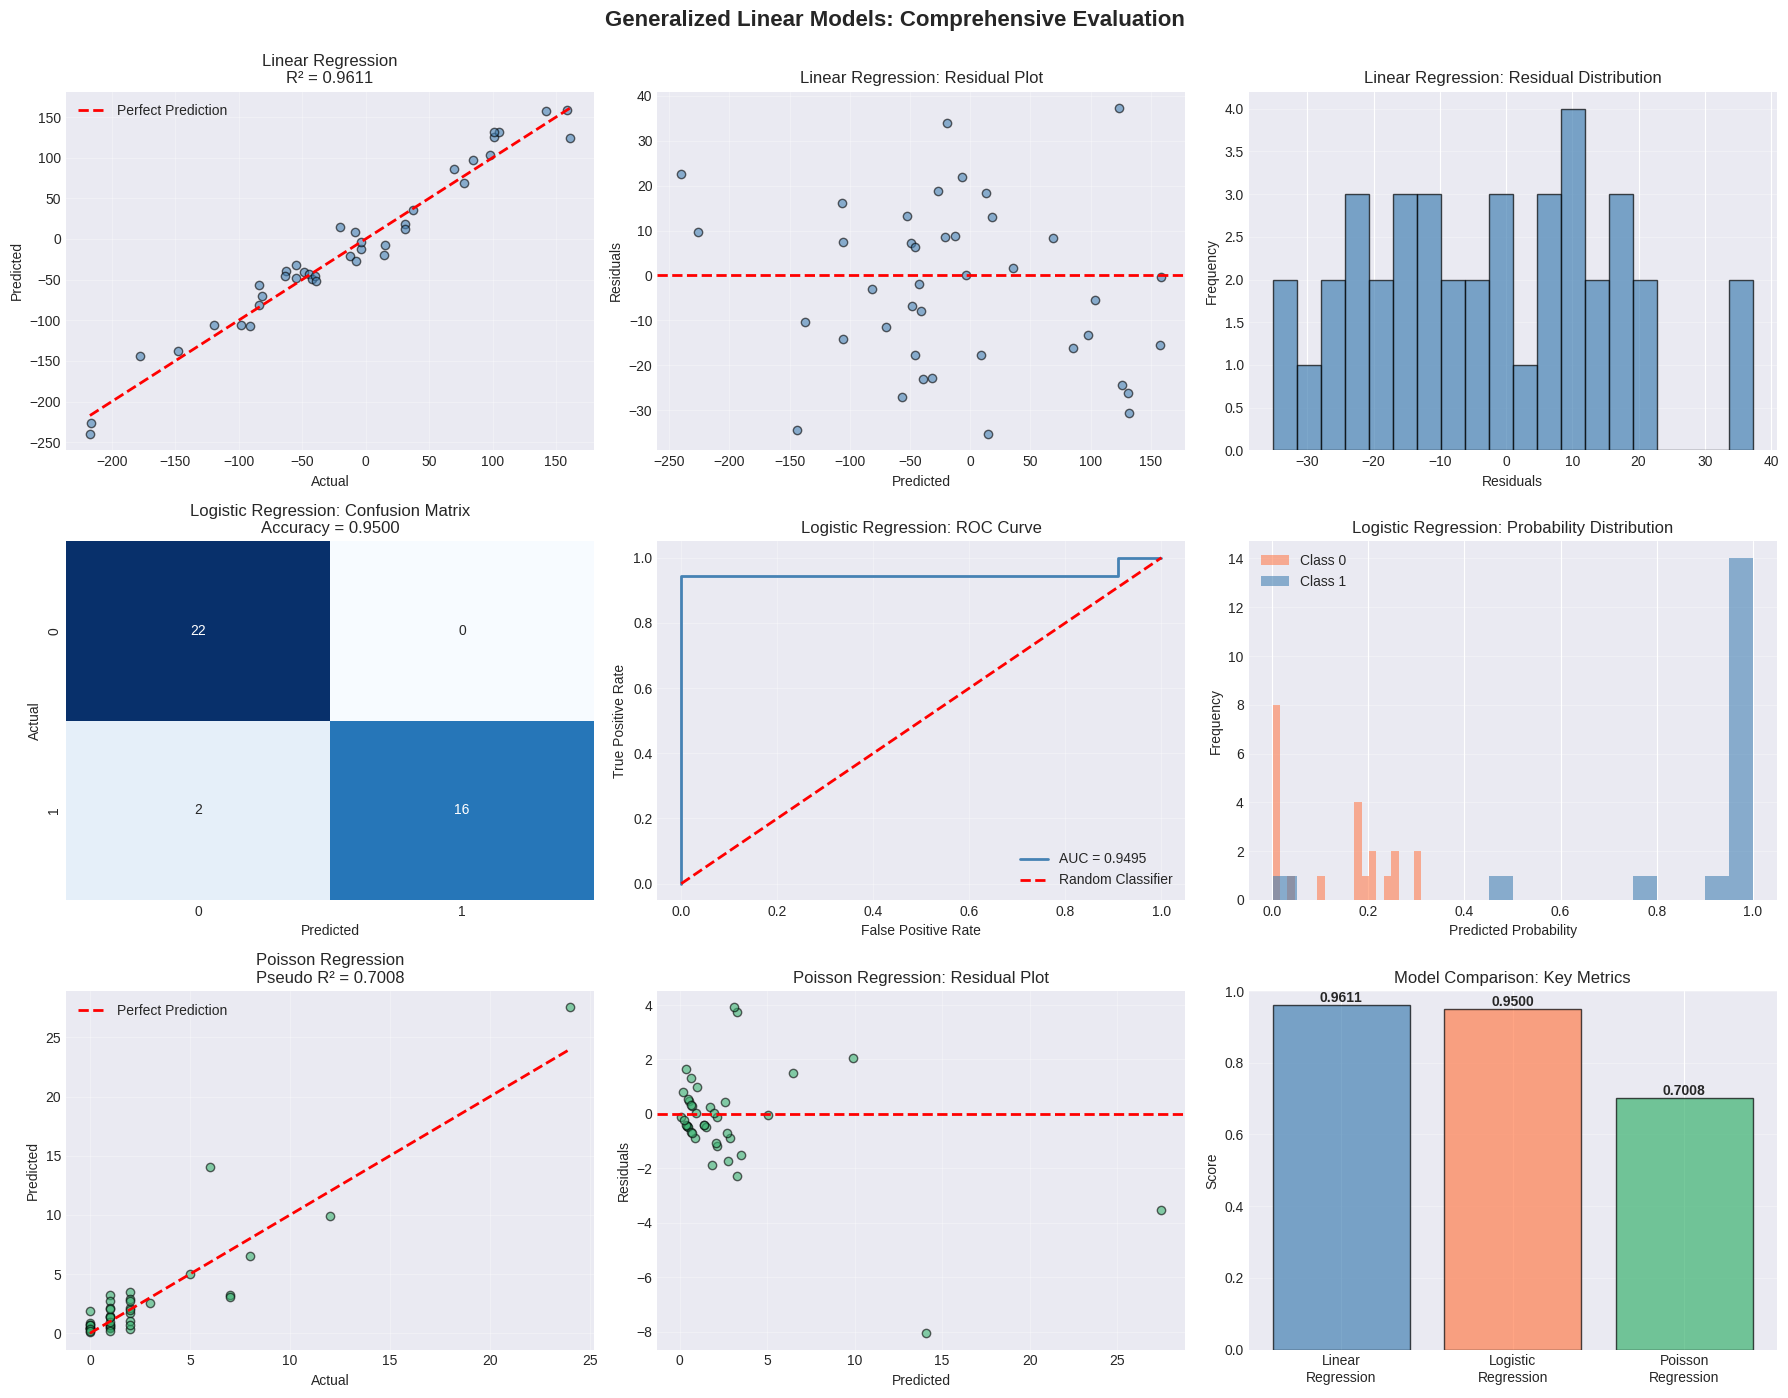

✓ Visualizations complete!


In [36]:
print("\nGenerating visualizations...")

fig = plt.figure(figsize=(18, 14))

# 1. Linear Regression: Predicted vs Actual
ax1 = plt.subplot(3, 3, 1)
ax1.scatter(y_test_reg, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='black')
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Linear Regression\nR² = {lr_results["r2"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Linear Regression: Residuals
ax2 = plt.subplot(3, 3, 2)
residuals_lr = y_test_reg - y_pred_lr
ax2.scatter(y_pred_lr, residuals_lr, alpha=0.6, color='steelblue', edgecolors='black')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Residuals')
ax2.set_title('Linear Regression: Residual Plot')
ax2.grid(True, alpha=0.3)

# 3. Linear Regression: Residuals Distribution
ax3 = plt.subplot(3, 3, 3)
ax3.hist(residuals_lr, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Linear Regression: Residual Distribution')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Logistic Regression: Confusion Matrix
ax4 = plt.subplot(3, 3, 4)
cm_log = confusion_matrix(y_test_class, y_pred_logreg)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title(f'Logistic Regression: Confusion Matrix\nAccuracy = {logreg_results["accuracy"]:.4f}')

# 5. Logistic Regression: ROC Curve
ax5 = plt.subplot(3, 3, 5)
fpr, tpr, _ = roc_curve(y_test_class, y_pred_proba_logreg)
ax5.plot(fpr, tpr, lw=2, label=f'AUC = {auc_logreg:.4f}', color='steelblue')
ax5.plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier')
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('Logistic Regression: ROC Curve')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Logistic Regression: Prediction Probabilities
ax6 = plt.subplot(3, 3, 6)
ax6.hist(y_pred_proba_logreg[y_test_class == 0], bins=20, alpha=0.6, label='Class 0', color='coral')
ax6.hist(y_pred_proba_logreg[y_test_class == 1], bins=20, alpha=0.6, label='Class 1', color='steelblue')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_title('Logistic Regression: Probability Distribution')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Poisson Regression: Predicted vs Actual
ax7 = plt.subplot(3, 3, 7)
ax7.scatter(y_test_count, y_pred_poisson, alpha=0.6, color='mediumseagreen', edgecolors='black')
ax7.plot([y_test_count.min(), y_test_count.max()], 
         [y_test_count.min(), y_test_count.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax7.set_xlabel('Actual')
ax7.set_ylabel('Predicted')
ax7.set_title(f'Poisson Regression\nPseudo R² = {poisson_results_dict["pseudo_r2"]:.4f}')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Poisson Regression: Residuals
ax8 = plt.subplot(3, 3, 8)
residuals_poisson = y_test_count - y_pred_poisson
ax8.scatter(y_pred_poisson, residuals_poisson, alpha=0.6, color='mediumseagreen', edgecolors='black')
ax8.axhline(y=0, color='r', linestyle='--', lw=2)
ax8.set_xlabel('Predicted')
ax8.set_ylabel('Residuals')
ax8.set_title('Poisson Regression: Residual Plot')
ax8.grid(True, alpha=0.3)

# 9. Model Comparison: R² and Accuracy
ax9 = plt.subplot(3, 3, 9)
models = ['Linear\nRegression', 'Logistic\nRegression', 'Poisson\nRegression']
metrics = [lr_results['r2'], logreg_results['accuracy'], poisson_results_dict['pseudo_r2']]
colors_bar = ['steelblue', 'coral', 'mediumseagreen']
bars = ax9.bar(models, metrics, color=colors_bar, alpha=0.7, edgecolor='black')
ax9.set_ylabel('Score')
ax9.set_title('Model Comparison: Key Metrics')
ax9.set_ylim([0, 1])
ax9.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, metric in zip(bars, metrics):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
            f'{metric:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Generalized Linear Models: Comprehensive Evaluation', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete!")

## 10. Summary and Key Takeaways

### What is a Generalized Linear Model?

A GLM is a flexible framework that extends linear regression to handle various types of response variables by:
1. Allowing response distributions beyond normal (Poisson, Binomial, Gamma, etc.)
2. Using link functions to relate predictors to response means
3. Accommodating heterogeneous variances

### Key Components

| Component | Purpose | Example |
|-----------|---------|---------|
| **Random Component** | Specifies response distribution | Gaussian, Binomial, Poisson |
| **Systematic Component** | Linear predictor η = Xβ | Combines features with weights |
| **Link Function** | Connects mean to predictor | Identity, Logit, Log |

### Common GLM Models

**Linear Regression:**
- Distribution: Gaussian
- Link: Identity
- Use: Continuous response, OLS estimation

**Logistic Regression:**
- Distribution: Binomial
- Link: Logit
- Use: Binary classification, probability prediction

**Poisson Regression:**
- Distribution: Poisson
- Link: Log
- Use: Count data, rate modeling

### Model Selection Guidelines

| Scenario | Recommended Model | Reason |
|----------|------------------|--------|
| Continuous response | Linear Regression | Natural for unbounded values |
| Binary outcome (0/1) | Logistic Regression | Constrains predictions to [0,1] |
| Count data | Poisson Regression | Ensures non-negative integer predictions |
| Positive continuous | Gamma Regression | Handles positive values with heterogeneous variance |
| Categorical (>2 classes) | Multinomial Logit | Extends logistic to multiple classes |

### Advantages of GLMs

✓ **Unified Framework:** Handles diverse data types within one framework
✓ **Interpretability:** Coefficients have clear interpretations
✓ **Efficiency:** Closed-form or efficient iterative solutions exist
✓ **Diagnostics:** Well-developed residual analysis and goodness-of-fit tests
✓ **Foundation for Advanced Methods:** Basis for mixed models, GAMs, and Bayesian methods

### Common Pitfalls to Avoid

✗ Ignoring distributional assumptions
✗ Using identity link with binary data (violates [0,1] constraint)
✗ Not checking overdispersion in Poisson models
✗ Misinterpreting log-odds in logistic regression
✗ Assuming linear relationships (always plot your data!)

### Further Exploration

- **Mixed Effects GLMs:** Add random effects for hierarchical data
- **Generalized Additive Models (GAMs):** Non-parametric relationships
- **Bayesian GLMs:** Incorporate prior information
- **Robust GLMs:** Reduce impact of outliers
- **Zero-Inflated Models:** Handle excess zeros in count data

---
## Practice Exercises

### Conceptual Questions

**1.** A GLM has three components: (a) a distribution from the exponential family, (b) a linear predictor $\eta = \theta^T x$, and (c) a link function $g$ such that $\mathbb{E}[y|x] = g^{-1}(\eta)$. Fill in the table:

| Model | Distribution | Link function $g$ | $\mathbb{E}[y\|x]$ |
|-------|-------------|-------------------|-------------------|
| Linear regression | Gaussian | ? | ? |
| Logistic regression | Bernoulli | ? | ? |
| Poisson regression | Poisson | ? | ? |

**2.** In a GLM, we assume $y | x; \theta \sim \text{ExponentialFamily}(\eta)$ with $\eta = \theta^T x$. Why is it natural — and not just a coincidence — that the **canonical link function** sets $\mathbb{E}[y|x] = \theta^T x$ for Gaussian and $\mathbb{E}[y|x] = \sigma(\theta^T x)$ for Bernoulli?

**3.** Derive the gradient of the log-likelihood for a general GLM and show it has the form $\nabla_\theta \ell(\theta) = \sum_i (y_i - \hat{y}_i) x_i$, regardless of which exponential family distribution is used. Why is this a surprisingly clean result?

**4.** What is the **dispersion parameter** $\phi$ in the exponential family form? Which distributions have a fixed $\phi = 1$ (no free dispersion), and for which is $\phi$ a free parameter to estimate?

**5.** Poisson regression assumes $y | x \sim \text{Poisson}(\lambda)$ with $\lambda = e^{\theta^T x}$. Why is the log link natural here (rather than the identity link $\lambda = \theta^T x$)? What would go wrong if you used the identity link directly?

**6.** GLMs are standardly fitted with **IRLS** (Iteratively Reweighted Least Squares), not gradient ascent. Explain what IRLS does at each step and why it converges much faster than gradient ascent. Under what practical conditions would you prefer gradient ascent or SGD over IRLS?

---

### Numerical Exercises

**7.** Implement Poisson regression from scratch using gradient ascent on the Poisson log-likelihood. Generate synthetic count data from $y_i \sim \text{Poisson}(e^{\theta^T x_i})$ with known $\theta$, and verify your implementation recovers $\theta$.

**8.** Compare Poisson regression vs OLS on heteroskedastic count data (variance grows with the mean). Generate such data, fit both models, and compare: (a) coefficient estimates, (b) residual plots, (c) prediction quality. Which model is more appropriate and why?

**9.** Fit a GLM for each distribution type (Gaussian, Bernoulli, Poisson) using `statsmodels.api.GLM`. Inspect the summary output. What does the **deviance** measure, and how is it analogous to RSS in linear regression?

---

### Reflection

**10.** The GLM framework unifies linear regression, logistic regression, and Poisson regression under a single theory. What does this unification buy you practically? If you were building a model for a new response type (e.g., exponential survival times), what steps would you follow to derive the appropriate GLM and its IRLS update?